# AI 기술면접관 (LoRA, 양자화 없음)

이 노트북은 **Qwen/Qwen3-1.7B** 모델을 양자화하지 않고 `bf16`으로 불러온 뒤, **LoRA 어댑터만 학습**해서 답변 말투를 사극체로 바꾸는 실습입니다.

핵심 흐름은 다음과 같습니다.

1. 파인튜닝 전 기본 모델의 답변을 확인합니다.
2. 현대어 질문 → 사극체 답변 쌍 40개를 `prompt` / `completion` 형태로 만듭니다.
3. 원본 모델 가중치는 고정하고 LoRA 어댑터만 학습합니다.
4. 같은 질문에 대해 파인튜닝 전/후 답변을 비교합니다.
5. 학습된 LoRA 어댑터만 파일로 저장합니다.

> 이 노트북은 **QLoRA가 아닙니다.** 모델 가중치를 4bit로 불러오지 않습니다. 다만 학습 시 VRAM을 아끼기 위해 optimizer는 `paged_adamw_8bit`를 사용합니다.


In [1]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

먼저 Python, PyTorch, CUDA, GPU, VRAM 상태를 확인합니다. 이 실습은 **Python 3.12 + JupyterLab** 환경을 기준으로 작성되었습니다.

- NVIDIA GPU가 정상적으로 인식되어야 합니다.
- 기본 설정은 8GB VRAM급 GPU에서도 실행되도록 보수적으로 잡았습니다.
- VRAM이 부족하면 뒤쪽 학습 설정에서 `max_length`를 줄이거나 `gradient_accumulation_steps`를 조정하세요.


In [2]:
import torch, platform

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"총 VRAM: {total_vram:.1f} GB")
else:
    print("⚠️ GPU가 감지되지 않았습니다. NVIDIA 드라이버 / CUDA 설치를 확인하세요.")


Python 버전: 3.12.3
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB


## 1. 패키지 설치 및 버전 확인

처음 실행하는 환경이라면 필요한 패키지를 한 번만 설치합니다. 이미 설치되어 있다면 설치 셀은 건너뛰고, 바로 버전 확인 셀만 실행해도 됩니다.

이 노트북에서 사용하는 주요 패키지는 다음과 같습니다.

- `transformers`: Qwen 모델과 tokenizer 로드
- `peft`: LoRA 어댑터 구성 및 저장
- `trl`: `SFTTrainer`를 이용한 지도 미세조정
- `bitsandbytes`: `paged_adamw_8bit` optimizer 사용
- `datasets`: 학습 데이터셋 구성

> 여기서 `bitsandbytes`를 쓰지만, 이 노트북은 모델을 4bit로 양자화하지 않습니다. `bitsandbytes`는 optimizer 메모리 절약을 위해 사용됩니다.


In [3]:
# 최초 1회만 실행하세요. (앞의 # 을 지우고 실행)
# uv add "transformers>=5.10.1" "peft>=0.19.0" "trl>=0.24.0" "bitsandbytes>=0.48.0" \
#     "accelerate>=1.11.0" "datasets>=3.0.0" sentencepiece protobuf -U


In [4]:
import datasets

In [5]:
import transformers, peft, trl, bitsandbytes, accelerate

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [6]:
print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


-> transformers 버전5점대 사용해야함

In [7]:
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

## 2. 모델 로드 (양자화 없음 · bf16)

기본 모델은 **`Qwen/Qwen3-1.7B`** 입니다. 이 셀에서는 `BitsAndBytesConfig` 없이 모델을 그대로 `bf16`으로 GPU에 올립니다.

코드에서 중요한 부분은 다음과 같습니다.

- `torch_dtype=torch.bfloat16`: 모델을 bf16 정밀도로 로드합니다.
- `device_map={"": 0}`: 단일 GPU 0번에 모델을 명시적으로 올립니다.
- `tokenizer.pad_token`이 없으면 `eos_token`으로 대체합니다.

이번 실습의 목적은 양자화 기법이 아니라 **LoRA 어댑터가 답변 스타일을 어떻게 바꾸는지** 확인하는 것입니다.


In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID) # 모델마다 토크나이저가 다르기때문에 모델에 맞는 토크나이저 자동 생성
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)

print("모델 로드 완료! (양자화 없음, bf16)")
if torch.cuda.is_available():
    print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

모델 로드 완료! (양자화 없음, bf16)
현재 GPU 메모리 사용량: 3.20 GB


## 3. 응답 생성 함수

`ask()` 함수는 같은 질문을 파인튜닝 전과 후에 반복해서 테스트하기 위한 헬퍼 함수입니다.

- `tokenizer.apply_chat_template()`으로 Qwen 채팅 형식에 맞는 입력 문장을 만듭니다.
- `enable_thinking=False`로 thinking 모드가 아니라 일반 답변 모드로 생성합니다.
- `model.eval()`을 호출해 생성 중 LoRA dropout이 켜지지 않도록 합니다.
- `torch.no_grad()`로 추론 중 gradient 계산을 끕니다.


In [9]:
SYSTEM_PROMPT = (
    "지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라."
)

In [10]:
def ask(question, max_new_tokens=200):
    model.eval()  # LoRA dropout이 켜진 채 생성하면 답변이 불안정해지므로 항상 eval 모드로 고정
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": question}]
    # 토크나이저로 text 토큰화
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.8,
            repetition_penalty=1.10,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    return response.strip()


## 4. Before: 파인튜닝 전 응답 확인

학습 전 모델이 같은 질문에 어떻게 답하는지 확인합니다. 이 결과는 `before_answers`에 저장해 두고, 학습 후 답변과 나란히 비교합니다.


In [11]:
torch.cuda.is_bf16_supported()

True

In [12]:
import importlib.metadata as md

print(md.version("nvidia-cublas-cu12"))

12.9.1.4


In [13]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Capability:", torch.cuda.get_device_capability(0))

x = torch.randn(64, 64, device="cuda", dtype=torch.bfloat16)
print("FP16 테스트:", (x @ x).shape)

PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Capability: (8, 9)
FP16 테스트: torch.Size([64, 64])


In [14]:
test_questions = [
    "직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.",
    "직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.",
    "직무: 데이터 에널리스트 경험: 공공데이터를 바탕으로 테블로를 이용해서 데이터를 시각화해보았다."
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q)
    before_answers[q] = ans
    print(f"\nQ: {q}\nA: {ans}")
    print("-" * 50)


파인튜닝 전(Before) 응답

Q: 직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.
A: 다음은 **Vision AI 모델 개発자**에 해당하는 **심층 기술흥취질문 3가지**, 지원자의 경험이 반영된 실용적인 질문입니다. 각 질문은 **기술적 이해도**, **실무 경험**, ** 문제 해결 능력** 등을 평가합니다.

---

### 🔍 1. **모델 레이블링 및 데이터 준비 과정에서 도전했었던 문제와 어떻게 해결한 경우?**

**질문:**  
"최근 작업 중에는 어떤 라ベル링 도전 문제가 있었나요? 그 때는 어떻게 접근했고, 어떤 방법을 사용해 문제를 해결했나요?"

**설명:**  
- 이 질문은 지원자가 **데이터 전처리 과제**에서 겪은 실제 문제를 설명하고, **해결 방식**과 **추상화된 사고**를 묻습니다
--------------------------------------------------

Q: 직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.
A: 다음은 지원자가 **PyTorch**를 활용한 AI 모델 개발 및 평결정 방식에 대한 **심층 기술퀄리티 면접 질문** 3가지를 제안합니다. 각 질문은 지적 능력, 문제 해결 능력을 측정하며, 실제 기술적 실무 경험을 테스트하는 데 적합합니다.

---

### **1. PyTorch 모델 설계 시 고려해야 할 요소**

**질문:**  
"PyTCC를 사용하여 AI 모del을 설計할 때, 어떤 요소들을 고려하시나요? 예를 들어, 데이터의 특성, 모델의 성능 평가는 어떻게 결정되나요?"

**설명:**  
이 질문은 지원자의 **모델 설 계 전략**, **데이터 분석 능**, 그리고 **평가 지표 설계 능**을 �
--------------------------------------------------

Q: 직무: 데이터 에널리스

## 5. 데이터셋 준비

현대어 질문과 사극체 답변 쌍 40개를 학습 데이터로 사용합니다. 다음 셀에서는 원본 리스트를 Hugging Face `Dataset`으로 바꾼 뒤, 각 예제를 `prompt`와 `completion`으로 변환합니다.

- `prompt`: 사용자 질문과 assistant 시작 토큰까지 포함한 입력 부분
- `completion`: 모델이 학습해야 하는 사극체 답변 부분

뒤쪽 `SFTConfig`에서 `completion_only_loss=True`를 사용하므로, loss는 주로 `completion` 부분에만 계산됩니다. 즉, 모델은 질문 문장을 외우기보다 **assistant 답변 말투**를 배우게 됩니다.


In [15]:
from datasets import load_dataset


raw_dataset = load_dataset(
    "json",
    data_files="datas/ai_interview_sft.jsonl",
    split="train",
)


print("학습 데이터 개수:", len(raw_dataset))
print("컬럼:", raw_dataset.column_names)


sample = raw_dataset[0]
print("SYSTEM:", sample["instruction"])
print("USER:", sample["input"])
print("ASSISTANT:", sample["output"])


학습 데이터 개수: 31
컬럼: ['instruction', 'input', 'output']
SYSTEM: 지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
USER: 직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.
ASSISTANT: 1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?


In [16]:
def format_example(example):
    prompt = tokenizer.apply_chat_template(
        [
            {
                "role": "system",
                "content": example["instruction"].strip(),
            },
            {
                "role": "user",
                "content": example["input"].strip(),
            },
        ],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    completion = example["output"].strip() + tokenizer.eos_token

    return {
        "prompt": prompt,
        "completion": completion,
    }


dataset = raw_dataset.map(
    format_example,
    remove_columns=raw_dataset.column_names,
)

print("PROMPT:")
print(dataset[0]["prompt"])
print("\nCOMPLETION:")
print(dataset[0]["completion"])

PROMPT:
<|im_start|>system
지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.<|im_end|>
<|im_start|>user
직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.<|im_end|>
<|im_start|>assistant
<think>

</think>



COMPLETION:
1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?<|im_end|>


## 6. LoRA 어댑터 설정 (양자화 없음)

이 노트북은 QLoRA가 아니므로 `prepare_model_for_kbit_training()`을 사용하지 않습니다. 대신 다음 순서로 순정 LoRA 학습을 준비합니다.

1. `model.gradient_checkpointing_enable()`로 메모리 사용량을 줄입니다.
2. `model.enable_input_require_grads()`로 gradient checkpointing 환경에서 입력 gradient를 허용합니다.
3. `LoraConfig`로 어댑터 설정을 정의합니다.
4. `get_peft_model()`로 원본 모델에 LoRA 어댑터를 붙입니다.

| 파라미터 | 의미 | 이번 실습 값 |
|---|---|---|
| `r` | LoRA rank. 클수록 표현력과 메모리 사용량이 증가합니다. | 16 |
| `lora_alpha` | LoRA scaling 계수입니다. | 32 |
| `lora_dropout` | 과적합 방지용 dropout입니다. | 0.05 |
| `target_modules` | LoRA를 붙일 attention/MLP projection layer입니다. | `q/k/v/o`, `gate/up/down` |

`model.print_trainable_parameters()` 결과에서 학습 가능한 파라미터가 0보다 커야 정상입니다. 0으로 나오면 LoRA 어댑터가 학습 대상이 아니므로, 모델 로드 셀부터 이 셀까지 순서대로 다시 실행하세요.


In [17]:
from peft import LoraConfig, get_peft_model

model.gradient_checkpointing_enable()
model.enable_input_require_grads()
# y = W x + (α / r) B A x
# W x              = 원본 모델의 출력
# (α / r) B A x    = LoRA adapter가 만든 보정 출력
# α / r은 LoRA 보정 출력이 원본 출력에 얼마나 강하게 반영될지 조절하는 값
# scale = (α / r)
# r : r = adapter 크기, 표현력, 병목 차원
# α : LoRA adapter의 영향력 크기를 조절하는 하이퍼파라미터
# α는 adapter의 학습 파라미터 수를 늘리는 값이 아니다. 오직 보정값의 세기를 조절한다.
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030


## 7. 학습 설정 및 실행

`SFTTrainer`로 사극체 답변을 지도 미세조정합니다. 이 실습은 작은 데이터셋으로 스타일 변화를 확인하는 것이 목적이므로, 전체 모델이 아니라 LoRA 어댑터만 업데이트합니다.

주요 설정은 다음과 같습니다.

- `per_device_train_batch_size=1`: GPU 메모리를 아끼기 위해 실제 배치는 1로 둡니다.
- `gradient_accumulation_steps=8`: 8번의 mini-batch를 모아 한 번 업데이트합니다.
- `learning_rate=2e-4`: LoRA 학습에서 자주 쓰는 범위의 학습률입니다.
- `bf16=True`: bf16 연산을 사용합니다.
- `optim="paged_adamw_8bit"`: optimizer 상태 메모리를 절약합니다.
- `max_length=512`: 입력과 출력 토큰을 합친 최대 길이입니다.
- `completion_only_loss=True`: 질문이 아니라 assistant 답변 부분 위주로 loss를 계산합니다.

학습이 끝나면 `model.eval()`로 전환합니다. LoRA dropout이 켜진 train mode에서 생성하면 답변이 불안정해질 수 있기 때문입니다.

> 오류 점검: loss가 전혀 줄지 않거나 학습이 되는 것처럼 보이는데 결과가 변하지 않으면, `model.print_trainable_parameters()`에서 trainable parameter가 0이 아닌지 먼저 확인하세요.


In [20]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./output/sample_a1_interview_lora",
    #num_train_epochs=8,
    max_steps=80,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",
    logging_steps=1,
    save_strategy="no",
    bf16=True,
    fp16=False,
    optim="paged_adamw_8bit",
    max_length=512,
    completion_only_loss=True,
    eos_token=tokenizer.eos_token,
    report_to="none",

    seed=SEED,
    data_seed=SEED
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,
)

train_result = trainer.train()

{'loss': '0.008918', 'grad_norm': '0.009203', 'learning_rate': '0', 'entropy': '0.7192', 'num_tokens': '1337', 'mean_token_accuracy': '1', 'epoch': '0.2581'}
{'loss': '0.007974', 'grad_norm': '0.008601', 'learning_rate': '5e-05', 'entropy': '0.7204', 'num_tokens': '2702', 'mean_token_accuracy': '1', 'epoch': '0.5161'}
{'loss': '0.007885', 'grad_norm': '0.01048', 'learning_rate': '0.0001', 'entropy': '0.7128', 'num_tokens': '4083', 'mean_token_accuracy': '1', 'epoch': '0.7742'}
{'loss': '0.009215', 'grad_norm': '0.05943', 'learning_rate': '0.00015', 'entropy': '0.7173', 'num_tokens': '5239', 'mean_token_accuracy': '1', 'epoch': '1'}
{'loss': '0.005248', 'grad_norm': '0.01098', 'learning_rate': '0.0002', 'entropy': '0.7133', 'num_tokens': '6567', 'mean_token_accuracy': '1', 'epoch': '1.258'}
{'loss': '0.005897', 'grad_norm': '0.0328', 'learning_rate': '0.0001999', 'entropy': '0.7079', 'num_tokens': '7950', 'mean_token_accuracy': '1', 'epoch': '1.516'}
{'loss': '0.02099', 'grad_norm': '0.

In [21]:
peak_vram = torch.cuda.max_memory_allocated() / 1024**3

print(f"학습 소요 시간: {train_result.metrics['train_runtime']:.1f}초")
print(f"학습 중 최대 VRAM: {peak_vram:.2f} GB")


# 학습이 끝나면 반드시 eval 모드로 전환합니다.
# (LoRA dropout이 생성 중에도 계속 켜져 있으면 답변이 불안정해집니다)
model.eval()
print("학습 완료! model.eval() 적용됨 — 이제 안정적으로 답변을 생성할 수 있습니다.")

학습 소요 시간: 204.3초
학습 중 최대 VRAM: 4.07 GB
학습 완료! model.eval() 적용됨 — 이제 안정적으로 답변을 생성할 수 있습니다.


,step,loss
60,61,0.000872
61,62,0.000871
62,63,0.000873
63,64,0.000877
64,65,0.000885
65,66,0.000815
66,67,0.000822
67,68,0.000876
68,69,0.000828
69,70,0.000826


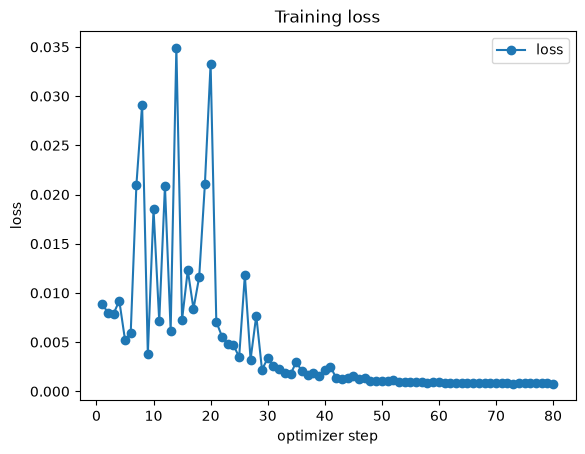

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 8. After: 파인튜닝 후 응답 비교

학습 전에 저장해 둔 `before_answers`와 학습 후 `ask()` 결과를 나란히 출력합니다. 사극체 어미와 표현이 일관되게 나타나는지 확인합니다.


In [23]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q)
    print(f"\nQ: {q}")
    print(f"[Before] {before_answers[q]}")
    print(f"[After ] {after_ans}")
    print("-" * 50)


Before vs After 비교

Q: 직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.
[Before] 다음은 **Vision AI 모델 개発자**에 해당하는 **심층 기술흥취질문 3가지**, 지원자의 경험이 반영된 실용적인 질문입니다. 각 질문은 **기술적 이해도**, **실무 경험**, ** 문제 해결 능력** 등을 평가합니다.

---

### 🔍 1. **모델 레이블링 및 데이터 준비 과정에서 도전했었던 문제와 어떻게 해결한 경우?**

**질문:**  
"최근 작업 중에는 어떤 라ベル링 도전 문제가 있었나요? 그 때는 어떻게 접근했고, 어떤 방법을 사용해 문제를 해결했나요?"

**설명:**  
- 이 질문은 지원자가 **데이터 전처리 과제**에서 겪은 실제 문제를 설명하고, **해결 방식**과 **추상화된 사고**를 묻습니다
[After ] 1. RLE와 polygon이 각각 어떤 형태의 라ベル을 대표하는가요?
2. Loss가 잘 나온다고 하지만 예측 오차가 전체적으로 큰 이유를 설명해보세요.
3. 데이터에 불균형이 존재한다면 어떤 학습 조정을 고려하겠습니까?
--------------------------------------------------

Q: 직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.
[Before] 다음은 지원자가 **PyTorch**를 활용한 AI 모델 개발 및 평결정 방식에 대한 **심층 기술퀄리티 면접 질문** 3가지를 제안합니다. 각 질문은 지적 능력, 문제 해결 능력을 측정하며, 실제 기술적 실무 경험을 테스트하는 데 적합합니다.

---

### **1. PyTorch 모델 설계 시 고려해야 할 요소**

**질문:**  
"PyTCC를 사용하여 AI 모del을 설計할 때, 어떤 요소들을 고려하시나요? 예를 들어, 데이터의 특성, 모델의 성능 평가는 어떻게 결

## 9. LoRA 어댑터 저장

이 셀은 전체 모델이 아니라 **LoRA 어댑터만** 저장합니다. 저장 위치는 다음과 같습니다.

```text
./lora_adapters/exam4_sageuk_lora
```

어댑터만 저장하면 파일 크기가 작고, 나중에 같은 base model에 다시 붙여서 사용할 수 있습니다. 전체 모델로 배포하려면 별도의 병합 과정이 필요합니다.


In [24]:
ADAPTER_DIR = "./lora_adapters/exam4_sageuk_lora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/exam4_sageuk_lora


## 정리

이 노트북에서 확인한 내용은 다음과 같습니다.

- 양자화 없이 `Qwen/Qwen3-1.7B`를 bf16으로 로드했습니다.
- 원본 모델 전체를 학습하지 않고 LoRA 어댑터만 학습했습니다.
- `prompt` / `completion` 데이터 구조와 `completion_only_loss=True`를 사용해 assistant 답변 말투를 중심으로 학습했습니다.
- 파인튜닝 전/후 답변을 비교해 스타일 변화가 실제로 일어나는지 확인했습니다.
- 최종 산출물로 LoRA 어댑터를 저장했습니다.

다음 단계로는 저장된 어댑터를 다시 불러오거나, base model과 병합한 뒤 Ollama 같은 로컬 실행 환경에 배포할 수 있습니다.
